In [66]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import mysql.connector

In [93]:
# Connect with database
db = mysql.connector.connect(host = 'localhost',
                            username = 'root',
                            password = 'mysql123',
                            database = 'ecommerce')

cur = db.cursor()

In [68]:
#list all unique cities where customers are located

In [69]:
query = """select distinct(customer_city) from customers"""

cur.execute(query)
data = cur.fetchall()
data

[('franca',),
 ('sao bernardo do campo',),
 ('sao paulo',),
 ('mogi das cruzes',),
 ('campinas',),
 ('jaragua do sul',),
 ('timoteo',),
 ('curitiba',),
 ('belo horizonte',),
 ('montes claros',),
 ('rio de janeiro',),
 ('lencois paulista',),
 ('caxias do sul',),
 ('piracicaba',),
 ('guarulhos',),
 ('pacaja',),
 ('florianopolis',),
 ('aparecida de goiania',),
 ('santo andre',),
 ('goiania',),
 ('cachoeiro de itapemirim',),
 ('sao jose dos campos',),
 ('sao roque',),
 ('camacari',),
 ('resende',),
 ('sumare',),
 ('novo hamburgo',),
 ('sao luis',),
 ('sao jose',),
 ('santa barbara',),
 ('ribeirao preto',),
 ('ituiutaba',),
 ('taquarituba',),
 ('sao jose dos pinhais',),
 ('barrinha',),
 ('parati',),
 ('dourados',),
 ('trindade',),
 ('cascavel',),
 ('fortaleza',),
 ('brasilia',),
 ('pelotas',),
 ('porto alegre',),
 ('salto',),
 ('jundiai',),
 ('cacapava',),
 ('sao vicente',),
 ('uberlandia',),
 ('botelhos',),
 ('sao goncalo',),
 ('araucaria',),
 ('nova iguacu',),
 ('areia branca',),
 ('campo

#Count the number of orders placed in 2017.

In [70]:
query = """select count(order_id) from orders where year(order_purchase_timestamp) = 2017"""

cur.execute(query)
data = cur.fetchall()
#for all value
data
#for tuple 
data[0]
#for single value
print('total orders placed in 2017: ', data[0][0])

total orders placed in 2017:  225505


#Find the total sales per category.

In [71]:
query = """select upper(products.product_category) category, round(sum(payments.payment_value), 2) sales
from products join order_items
on products.product_id = order_items.product_id
join payments
on payments.order_id = order_items.order_id
group by category
"""

cur.execute(query)
data = cur.fetchall()
data

[('PERFUMERY', 63342332.49),
 ('FURNITURE DECORATION', 178772048.97),
 ('TELEPHONY', 60860256.34),
 ('BED TABLE BATH', 214069208.88),
 ('AUTOMOTIVE', 106536791.39),
 ('COMPUTER ACCESSORIES', 198166305.78),
 ('HOUSEWARES', 136844766.29),
 ('BABIES', 67480707.47),
 ('TOYS', 77379711.18),
 ('FURNITURE OFFICE', 80853310.89),
 ('COOL STUFF', 97462250.01),
 ('HEALTH BEAUTY', 207171639.92),
 ('PET SHOP', 38908621.29),
 ('GENERAL INTEREST BOOKS', 8086844.95),
 ('STATIONARY STORE', 39680008.71),
 ('WATCHES PRESENT', 178652084.82),
 ('PCS', 34890193.67),
 ('CLIMATIZATION', 11396332.44),
 ('CONSTRUCTION TOOLS CONSTRUCTION', 30184453.78),
 ('SPORT LEISURE', 174015944.89),
 ('BAGS ACCESSORIES', 23393911.3),
 ('ELECTRONICS', 32482137.46),
 ('CASA CONSTRUCAO', 17080661.29),
 ('GAMES CONSOLES', 24435047.39),
 ('FASHION BAGS AND ACCESSORIES', 27269785.0),
 ('HOME APPLIANCES', 11941533.73),
 ('GARDEN TOOLS', 104785093.85),
 ('AGRO INDUSTRIA E COMERCIO', 14841326.32),
 (None, 31600213.76),
 ('AUDIO', 754

In [72]:
#create DataFrame
df = pd.DataFrame(data, columns = ['Category', 'Sales'])
df

,Category,Sales
0,PERFUMERY,6.334233e+07
1,FURNITURE DECORATION,1.787720e+08
2,TELEPHONY,6.086026e+07
3,BED TABLE BATH,2.140692e+08
4,AUTOMOTIVE,1.065368e+08
...,...,...
69,CDS MUSIC DVDS,1.499288e+05
70,LA CUISINE,3.641912e+05
71,FASHION CHILDREN'S CLOTHING,9.820875e+04
72,PC GAMER,2.718038e+05


Calculate the percentage of orders that were paid in installments.

In [73]:
query = """select round((sum(case when payment_installments >= 1 then 1 
else 0 end))/count(*)*100, 2) from payments
"""

cur.execute(query)
data = cur.fetchall()
data 
print('the percentage of orders that were paid in installments is ', data[0][0])

the percentage of orders that were paid in installments is  100.00


Count the number of customers from each state.

In [74]:
query = """select customer_state, count(customer_id)
from customers group by customer_state
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ['Customer_state','customer_count']) 
df

,Customer_state,customer_count
0,SP,208730
1,SC,18185
2,MG,58175
3,PR,25225
4,RJ,64260
5,RS,27330
6,PA,4875
7,GO,10100
8,ES,10165
9,BA,16900


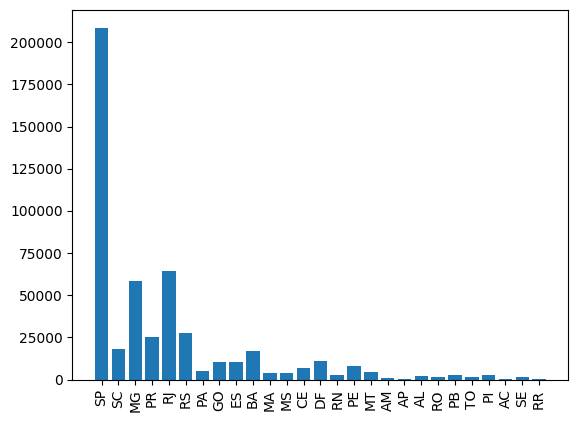

In [75]:
#visualization 
plt.bar(df['Customer_state'], df['customer_count'])
plt.xticks(rotation = 90)
plt.show()

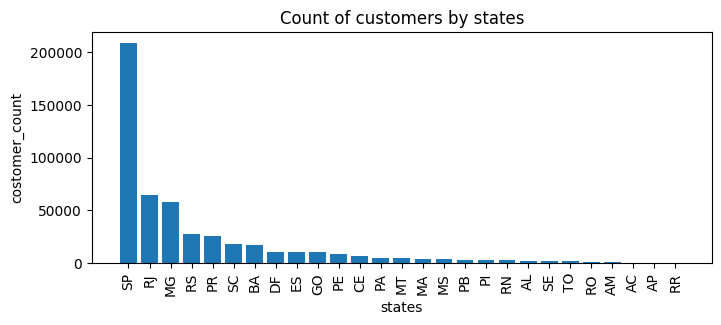

In [76]:
#with descending order and figure set up
df = pd.DataFrame(data, columns = ['Customer_state','customer_count'])
df = df.sort_values(by = 'customer_count', ascending = False)


plt.figure(figsize=(8,3))
plt.bar(df['Customer_state'], df['customer_count'])
plt.xticks(rotation = 90)
plt.xlabel('states')
plt.ylabel('costomer_count')
plt.title('Count of customers by states')

plt.show()

Calculate the number of orders per month in 2018.

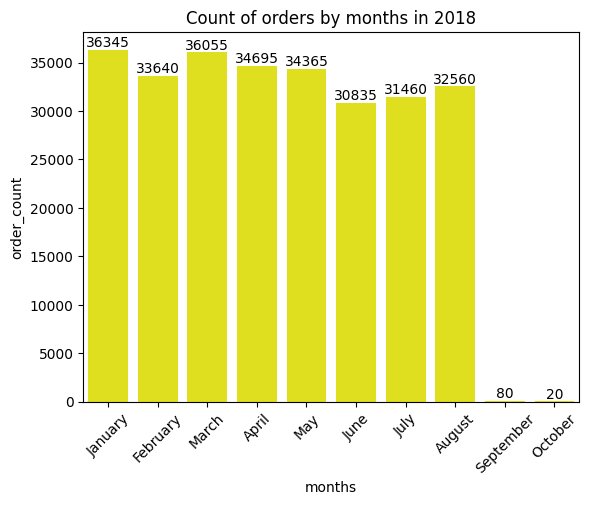

In [77]:
query = """select monthname(order_purchase_timestamp) months, count(order_id) order_count
from orders where year(order_purchase_timestamp) = 2018
group by months
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ['months', 'order_count'])
o = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October']
df

ax = sns.barplot(x = df['months'], y = df['order_count'], data = df, order = o,color = 'yellow')
plt.xticks(rotation = 45)
ax.bar_label(ax.containers[0])

plt.title('Count of orders by months in 2018')
plt.show()

Find the average number of products per order, grouped by customer city.

In [78]:
query = """with count_per_order as 
(select orders.order_id, orders.customer_id, 
count(order_items.order_id) as oc
from orders join order_items
on orders.order_id = order_items.order_id
group by orders.order_id, orders.customer_id)

select customers.customer_city, round(avg(count_per_order.oc), 2) as average_orders
from customers join count_per_order
on customers.customer_id = count_per_order.customer_id
group by customers.customer_city order by average_orders desc
"""

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ['Customer_city','average_orders']) 
df


,Customer_city,average_orders
0,padre carvalho,175.00
1,celso ramos,162.50
2,datas,150.00
3,candido godoi,150.00
4,matias olimpio,125.00
...,...,...
4105,sao mamede,25.00
4106,sambaiba,25.00
4107,japaratuba,25.00
4108,tuiuti,25.00


Calculate the percentage of total revenue contributed by each product category.

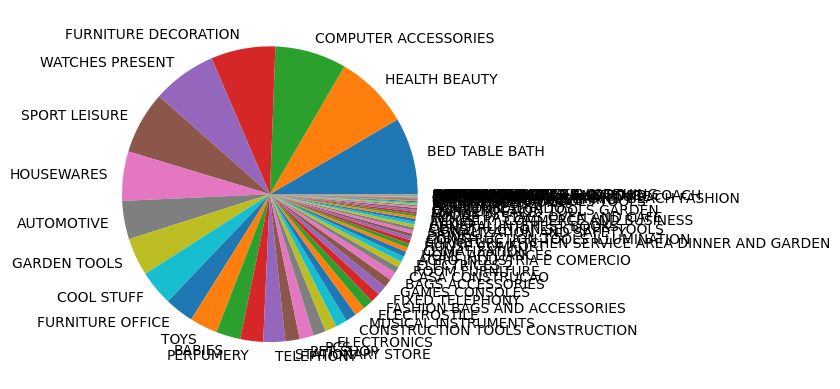

In [92]:
query = """select upper(products.product_category) category, 
round((sum(payments.payment_value)/(select sum(payment_value) from payments))*100, 2) sales_percentage
from products join order_items
on products.product_id = order_items.product_id
join payments
on payments.order_id = order_items.order_id
group by category order by sales_percentage desc
"""

cur.execute(query)
data = cur.fetchall()
df= pd.DataFrame(data, columns = ['category', 'sales_percentage'])
df.head(100)
#should avoid pie chart here
#plt.pie(df['sales_percentage'], labels = df['category'])
#plt.show()

#Identify the correlation between product price and the number of times a product has been purchased.

In [98]:
#import libraries
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import mysql.connector
import numpy as np


# Connect with database
db = mysql.connector.connect(host = 'localhost',
                            username = 'root',
                            password = 'mysql123',
                            database = 'ecommerce')

cur = db.cursor()



query = """select products.product_category, 
count(order_items.product_id),
round(avg (order_items.price), 2)
from products join order_items
on products.product_id= order_items.product_id
group by products.product_category
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ['Category', 'order_count', 'price'])
#df

arr1= df['order_count']
arr2= df['price']
a = np.corrcoef(arr1,arr2)
print('The correlation between price and number of times a product has been purchased is ', a[0][-1])

The correlation between price and number of times a product has been purchased is  -0.10631514167157564


Calculate the total revenue generated by each seller, and rank them by revenue.

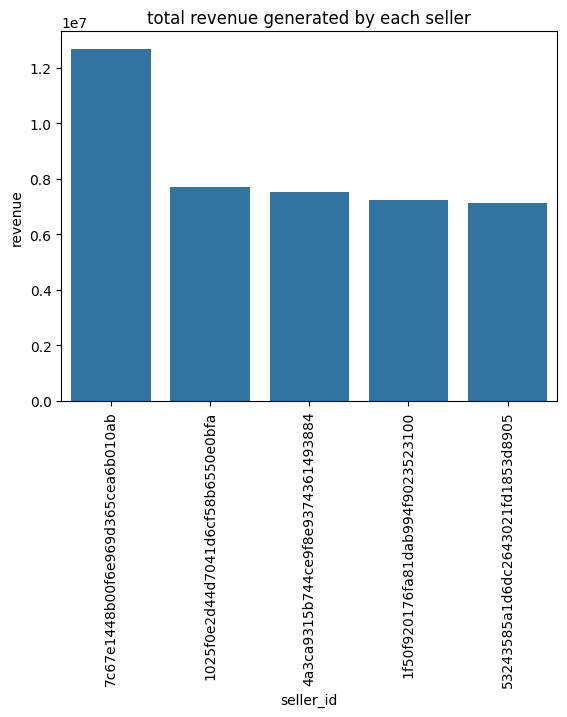

In [111]:
#import libraries
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import mysql.connector
import numpy as np


# Connect with database
db = mysql.connector.connect(host = 'localhost',
                            username = 'root',
                            password = 'mysql123',
                            database = 'ecommerce')

cur = db.cursor()



query = """select *, dense_rank() over(order by revenue desc) as rn from
(select order_items.seller_id, sum(payments.payment_value) 
revenue from order_items join payments
on order_items.order_id = payments.order_id
group by order_items.seller_id) as a
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ['seller_id', 'revenue', 'rank'])
df = df.head()

sns.barplot(x = 'seller_id', y = 'revenue', data = df).set(title = 'total revenue generated by each seller')
plt.xticks(rotation = 90)

plt.show()


Calculate the moving average of order values for each customer over their order history.

In [115]:
query = """select customer_id, order_purchase_timestamp,payment,
avg(payment) over(partition by customer_id order by order_purchase_timestamp
rows between 2 preceding and current row) as mov_avg
from
(select orders.customer_id, orders.order_purchase_timestamp,
payments.payment_value as payment
from payments join orders
on payments.order_id = orders.order_id)as a
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ['customer_id','order_purchase_timestamp','payment','mov_avg'])
df.head()

,customer_id,order_purchase_timestamp,payment,mov_avg
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
2,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
3,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
4,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998


Calculate the cumulative sales per month for each year.

In [116]:
query = """select years, months, payment,
sum(payment) over(order by years, months) as cumulative_sales 
from 
(select year(orders.order_purchase_timestamp) as years,
month(orders.order_purchase_timestamp) as months,
round(sum(payments.payment_value), 2) as payment from orders join payments
on orders.order_id = payments.order_id
group by years, months order by years, months)as a
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ['years','months','payment','cumulative_sales'])
df.head()

,years,months,payment,cumulative_sales
0,2016,9,6306.00,6306.00
1,2016,10,1477262.00,1483568.00
2,2016,12,490.50,1484058.50
3,2017,1,3462201.00,4946259.50
4,2017,2,7297700.24,12243959.74


Calculate the year-over-year growth rate of total sales.

In [125]:
query = """with a as(select year(orders.order_purchase_timestamp) as years,
round(sum(payments.payment_value), 2) as payment from orders join payments
on orders.order_id = payments.order_id
group by years order by years)

select years, ((payment - lag(payment, 1) over(order by years))/lag(payment, 1)over(order by years)) * 100 from a

"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ['years','yoy % growth'])
df.head()

,years,yoy % growth
0,2016,NaN
1,2017,12112.703759
2,2018,20.000924
